# test of code

In [1]:
import os
import sys
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy

# 1. Setup Project Path
# Assumes notebook is in experiments/exp2_benchmark/
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 2. Import Project Modules
from experiments.exp2_benchmark.config import (
    NETWORK_CONFIG, TRAIN_CONFIG, PATHS, EXPERIMENT_CONFIG
)
from neuronseek.utils.tabular_data_loader import load_dataset
from neuronseek.models.benchmark_nets import build_network, get_loss_fn

# 3. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Working Directory: {os.getcwd()}")
print(f"Project Root: {project_root}")
print(f"Device: {device}")

Working Directory: /root/workspace/NeuronSeek2.0/experiments/exp2_benchmark
Project Root: /root/workspace/NeuronSeek2.0
Device: cuda


In [2]:
def load_structure(dataset_name: str, structure_dir: str) -> dict:
    """Load structure info from JSON."""
    filepath = os.path.join(structure_dir, f"{dataset_name}_structure.json")
    if not os.path.exists(filepath):
        print(f"[Warning] Structure file not found: {filepath}. Using default.")
        return None
    with open(filepath, 'r') as f:
        return json.load(f)

def count_flops(model, input_shape):
    """
    Estimate FLOPs for Linear and Conv layers using hooks.
    Input shape should be (1, input_features).
    """
    flops = 0
    def linear_hook(module, input, output):
        nonlocal flops
        # Linear: y = xA^T + b. MACs = in_dim * out_dim
        # 1 MAC = 2 FLOPs (Multiply + Add)
        in_feat = input[0].shape[1]
        out_feat = output.shape[1]
        flops += 2 * in_feat * out_feat

    hooks = []
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            hooks.append(layer.register_forward_hook(linear_hook))
    
    # Dummy forward pass
    dummy_input = torch.randn(input_shape).to(next(model.parameters()).device)
    model.eval()
    with torch.no_grad():
        model(dummy_input)
    
    for h in hooks: h.remove()
    return flops

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def train_and_track(model, train_loader, val_loader, config, task, device):
    """
    Improved Training Loop with Differential Learning Rates & Gradient Clipping.
    """
    model.to(device)
    loss_fn = get_loss_fn(model.n_classes)

    params_dict = {
        'pure': [],   
        'interact': [], 
        'bias': [],   
        'bn': [],     
        'other': []   
    }

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        
        # 根据参数名关键词进行归类
        if 'pure_layers' in name and 'weight' in name:
            params_dict['pure'].append(param)
        elif 'int_params' in name: # CP factors (U, W)
            params_dict['interact'].append(param)
        elif 'bias' in name or 'beta' in name:
            params_dict['bias'].append(param)
        elif 'norms' in name or 'bn_' in name: # BN weights & bias
            params_dict['bn'].append(param)
        else:
            params_dict['other'].append(param) # e.g. output layer weights

    # 打印分组信息，确保没有遗漏
    # print(f"Params Grouping: Pure={len(params_dict['pure'])}, Int={len(params_dict['interact'])}, "
    #       f"Bias={len(params_dict['bias'])}, BN={len(params_dict['bn'])}, Other={len(params_dict['other'])}")

    # 构造优化器参数组 (参考 Searcher 的配置)
    optimizer_groups = [
        # Pure Stream: 较低 LR，标准 WD
        {'params': params_dict['pure'], 'lr': 0.005, 'weight_decay': 1e-4},
        
        # Interaction Stream (CP): 标准 LR，轻微 WD (初始化很小，需要动力)
        {'params': params_dict['interact'], 'lr': 0.01, 'weight_decay': 1e-5},
        
        # Bias: 较低 LR，无 WD !!!
        {'params': params_dict['bias'], 'lr': 0.005, 'weight_decay': 0.0},
        
        # BN: 标准 LR，无 WD
        {'params': params_dict['bn'], 'lr': 0.01, 'weight_decay': 0.0},
        
        # Output Layer / Others: 标准配置
        {'params': params_dict['other'], 'lr': 0.01, 'weight_decay': 1e-4},
    ]

    optimizer = torch.optim.Adam(optimizer_groups)
    
    # 使用 Cosine Annealing (比 StepLR 更平滑)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=1e-5
    )

    history = {'val_loss': []}
    best_val_loss = float('inf')
    
    for epoch in range(config['epochs']):
        # --- Train ---
        model.train()
        ep_train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            
            # [关键修改 2] 梯度裁剪 (Gradient Clipping)
            # 这对多项式网络至关重要，防止梯度爆炸导致的 Loss 震荡
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            ep_train_loss += loss.item() * len(X)
        
        # --- Validation ---
        model.eval()
        ep_val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_fn(pred, y)
                ep_val_loss += loss.item() * len(X)
        
        avg_val_loss = ep_val_loss / len(val_loader.dataset)
        history['val_loss'].append(avg_val_loss)
        
        scheduler.step()
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

    return history, best_val_loss

In [9]:
structure = {
  "NeuronSeek": {
    "pure_indices": [1],
    "interact_indices": [1, 2],
    "rank": 8
  },
  "TNSR": {
    "pure_indices": [1],
    "interact_indices": [],
    "rank": 1
  }
}

In [10]:
structure['NeuronSeek']

{'pure_indices': [1], 'interact_indices': [1, 2], 'rank': 8}

In [11]:
# ==========================================
# Configuration
# ==========================================
DATASET_NAME = 'california_housing'  # Change this to switch datasets
SEED = 42
STRUCTURE_DIR = PATHS['structure_dir']

# Load Data & Structure
torch.manual_seed(SEED)
np.random.seed(SEED)
data = load_dataset(DATASET_NAME, return_torch=True, random_state=SEED)

# Prepare Loaders
train_dataset = TensorDataset(data['X_train'], data['y_train'])
val_dataset = TensorDataset(data['X_val'], data['y_val'])
test_dataset = TensorDataset(data['X_test'], data['y_test'])

train_loader = DataLoader(train_dataset, batch_size=TRAIN_CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=TRAIN_CONFIG['batch_size'])
test_loader = DataLoader(test_dataset, batch_size=TRAIN_CONFIG['batch_size'])

models_config = {
    'MLP': {
        'arch': 'mlp', 
        'hidden_dims': [64, 32]
    },
    'KAN': {
        'arch': 'kan', 
        'hidden_dims': [64, 32], 
        'grid_size': 5
    },
    'NS-Net (Original)': {
        'arch': 'tasknet',
        'structure_info': structure['NeuronSeek'], # Pure=[1], Int=[1,2]
        'hidden_dims': [64, 32],
        'use_cp': False  # Independent Rank-1 (Fan's style)
    },
    'NS-Net (CP-Rank8)': {
        'arch': 'tasknet',
        'structure_info': structure['NeuronSeek'], # Pure=[1], Int=[1,2]
        'hidden_dims': [64, 32],
        'use_cp': True,  # Shared Basis CP
        'rank': 8        # 使用 rank=8
    },
    'TNSR-Net': {
        'arch': 'tasknet',
        'structure_info': structure['TNSR'], # Pure=[1], Int=[]
        'hidden_dims': [64, 32],
        'use_cp': False
    }
}


[DataLoader] Loaded 'california_housing' from sklearn
[DataLoader] california_housing: 8 features, train=14448, val=2064, test=4128, task=regression


Model                | Params   | FLOPs      | Test Loss 
------------------------------------------------------------
MLP                  | 2689     | 5184       | 0.2785    
KAN                  | 23328    | 0          | 0.2696    
NS-Net (Original)    | 10945    | 20544      | 3.8990    
NS-Net (CP-Rank8)    | 6529     | 5184       | 0.8876    
TNSR-Net             | 2881     | 5184       | 0.8037    


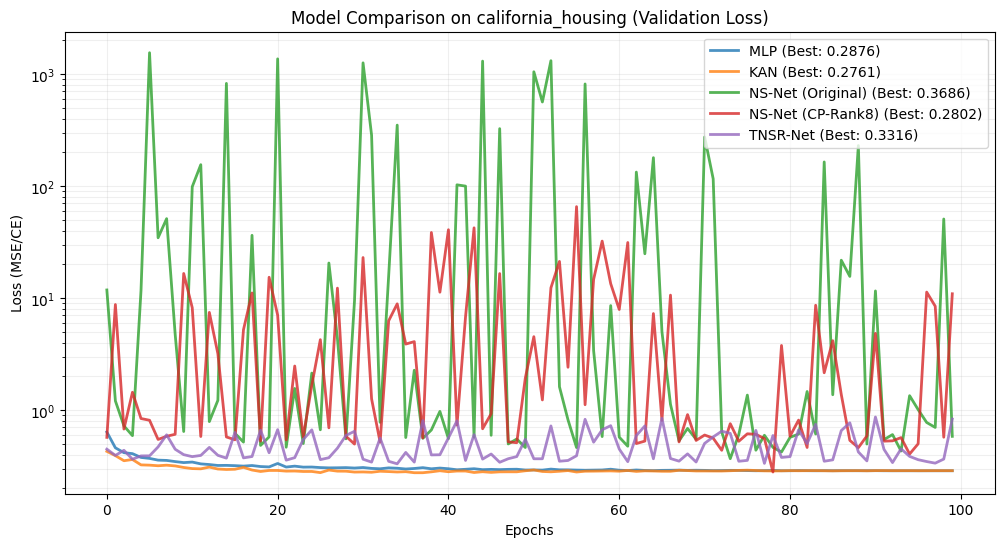

In [ ]:
results = {}
colors = ['gray', 'orange', 'blue', 'green', 'purple']

print(f"{'Model':<20} | {'Params':<8} | {'FLOPs':<10} | {'Test Loss':<10}")
print("-" * 60)

plt.figure(figsize=(12, 6))

for idx, (name, cfg) in enumerate(models_config.items()):
    # 1. Build
    try:
        model = build_network(
            in_features=data['n_features'],
            n_classes=data['n_classes'],
            **cfg
        )
    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue

    # 2. Stats
    n_params = count_params(model)
    flops = count_flops(model, (1, data['n_features']))
    
    # 3. Train
    hist, best_val = train_and_track(
        model, train_loader, val_loader, 
        TRAIN_CONFIG, data['task'], device
    )
    
    # 4. Final Test
    loss_fn = get_loss_fn(model.n_classes)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in test_loader:
            test_loss += loss_fn(model(X.to(device)), y.to(device)).item() * len(X)
    test_loss /= len(test_loader.dataset)
    
    print(f"{name:<20} | {n_params:<8} | {flops:<10.0f} | {test_loss:<10.4f}")
    
    # 5. Plot
    plt.plot(hist['val_loss'], label=f"{name} (Best: {best_val:.4f})", linewidth=2, alpha=0.8)

# ==========================================
# Finalize Plot
# ==========================================
plt.title(f"Model Comparison on {DATASET_NAME} (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE/CE)")
plt.yscale('log') # Log scale is often better for regression
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()